# Question 2: Three Methods for Option Pricing

In practice, derivatives are priced using a variety of techniques. In this section, we price the
same European call option using three different approaches—Black-Scholes (closed-form), Monte
Carlo simulation, and a binomial lattice—and compare them.

The chosen stock for the European call option is Eli Lilly and Company (LLY).

## 2.0 Setup

In [5]:
# Stock Ticker for Eli Lilly and Company (LLY)
ticker = "LLY"

# Stock price S0
# Most-current stock price (stock closed at $939.47 USD on April 10th, 2026)
stock_price = 939.47

# Risk-free rate r (annual % from FRED; decimal form for BS / MC formulas)
# Market Yield on U.S. Treasury Securities at 6-Month Constant Maturity (as of April 9th, 2026)
# https://fred.stlouisfed.org/series/DGS6MO
risk_free_rate_pct = 3.71
r = risk_free_rate_pct / 100.0

# At-the-money implied volatility σ from the Q1 volatility surface for LLY
implied_volatility = 0.2690

# At-the-money European call, 6 months to expiry (used in Problems 2.1–2.3)
time_to_expiry = 0.5  # years
strike_price = stock_price  # K = S0 (ATM)

# Monte Carlo (Problem 2.2): Euler–Maruyama time steps (Δt = T / n_steps)
mc_time_steps = 126
mc_seed = 42  # for reproducible simulations

## 2.1 Black-Scholes
(a) Compute the Black-Scholes price using the formula from Problem 1. This is your benchmark.

In [6]:
import numpy as np
from scipy.stats import norm


def bs_call(S, K, T, r, sigma):
    """
    Price the call option for stock S using the Black-Scholes European call
    formula from Question 1 (a)
    """
    with np.errstate(divide="ignore", invalid="ignore"):
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


# Define variables
S0 = stock_price  # Most-recent stock price
K = strike_price  # Strike price (K = S0 for an at-the-money call)
T = time_to_expiry  # Time to expiry (6 months as specified)
sigma = implied_volatility  # At-the-money implied volatility (from Question 1)

bs_benchmark_price = bs_call(S0, K, T, r, sigma)

print("Question 2.1: Black-Scholes benchmark (European ATM call for LLY)")
print(f"  LLY spot S0     : ${S0:,.2f}")
print(f"  Strike K        : ${K:,.2f}  (ATM: K = S0)")
print(f"  Time to expiry T: {T} years (6 months)")
print(f"  Risk-free r     : {r:.4f} ({risk_free_rate_pct}% p.a.)")
print(f"  Implied vol σ   : {sigma:.4f}")
print()
print(f"  Black-Scholes call price: ${bs_benchmark_price:,.4f}")

Question 2.1: Black-Scholes benchmark (European ATM call for LLY)
  LLY spot S0     : $939.47
  Strike K        : $939.47  (ATM: K = S0)
  Time to expiry T: 0.5 years (6 months)
  Risk-free r     : 0.0371 (3.71% p.a.)
  Implied vol σ   : 0.2690

  Black-Scholes call price: $79.4962


## 2.2 Monte Carlo

The fundamental pricing equation in derivatives says that the price of any contingent claim is the expected present value of its future cash flows under the risk-neutral measure. The problem is that this expectation is usually impossible to compute analytically—we don't have a closed-form expression for it. Monte Carlo sidesteps this by brute-forcing the expectation with a sample average: simulate $N$ independent draws of $S_T$, compute the payoff for each, average them, and discount. By the law of large numbers, the sample average converges to the true expectation as $N \to \infty$. The key ingredient is a model for how the stock price evolves.Under the risk-neutral measure, the stock price follows geometric Brownian motion:$$dS_t = r S_t \, dt + \sigma S_t \, dW_t$$This is a continuous-time stochastic differential equation (SDE). To simulate it on a computer, we need to discretize time. The Euler-Maruyama scheme approximates the SDE over a small time step $\Delta t$:$$S_{t+\Delta t} = S_t + r S_t \Delta t + \sigma S_t \sqrt{\Delta t} \, Z_t, \quad Z_t \sim \mathcal{N}(0,1)$$The $\sqrt{\Delta t}$ appears because Brownian motion increments scale as $\Delta W \sim \mathcal{N}(0, \Delta t)$, i.e., the standard deviation of a Brownian step over time $\Delta t$ is $\sqrt{\Delta t}$, not $\Delta t$. This square-root scaling is fundamental to stochastic calculus and is what distinguishes it from ordinary calculus.Simulate daily price paths using $n = 126$ time steps ($\Delta t = T/n$) to reach the terminal price $S_T$.The Monte Carlo price of a European call is then:$$\hat{C} = e^{-rT} \cdot \frac{1}{N} \sum_{i=1}^{N} \max(S_T^{(i)} - K, 0)$$where $S_T^{(1)}, \dots, S_T^{(N)}$ are $N$ independent simulated terminal prices. The standard error of the estimate is:$$\text{SE} = \frac{\hat{\sigma}_{\text{payoff}}}{\sqrt{N}}, \quad \text{where } \hat{\sigma}_{\text{payoff}} = \text{std}\left( \left\{ e^{-rT} \max(S_T^{(i)} - K, 0) \right\}_{i=1}^N \right)$$This tells you how precisely you have estimated the price. A 95% confidence interval is $\hat{C} \pm 1.96 \cdot \text{SE}$.


### (a) Convergence Plot

Run the simulation for a range of path counts (e.g., N = 100 up to N = 500,000) and plot the MC price ± 2 standard errors against the BS price. At what N does the MC estimate stabilize to within 1% of the BS price? Report the MC price, standard error, and 95% confidence interval at each N. Does the MC price converge exactly to the BS price?

Question 2.2: Monte Carlo (Euler–Maruyama, n = 126 steps, Δt = T/n)
  Simulated 500,000 terminal prices in 0.433 s (one stream, nested N for convergence).

  Smallest N on this grid with |MC − BS| / BS ≤ 1%: N = 384

  MC price, SE, and 95% CI at each N (grid):
     N  MC_price        SE  CI_95_low  CI_95_high  rel_err_vs_BS
   100 88.648196 14.351456  60.519343  116.777050       0.115125
   157 93.383884 11.315104  71.206280  115.561489       0.174697
   245 85.919246  8.350082  69.553086  102.285406       0.080797
   384 79.611578  6.380951  67.104914   92.118242       0.001452
   601 85.108417  5.287417  74.745079   95.471755       0.070598
   941 85.153983  4.116027  77.086570   93.221395       0.071171
  1473 81.938852  3.236076  75.596143   88.281561       0.030727
  2306 78.791125  2.522082  73.847845   83.734406       0.008869
  3610 79.723593  2.027896  75.748917   83.698269       0.002861
  5651 81.246727  1.642199  78.028017   84.465437       0.022021
  8848 81.154045  1.316

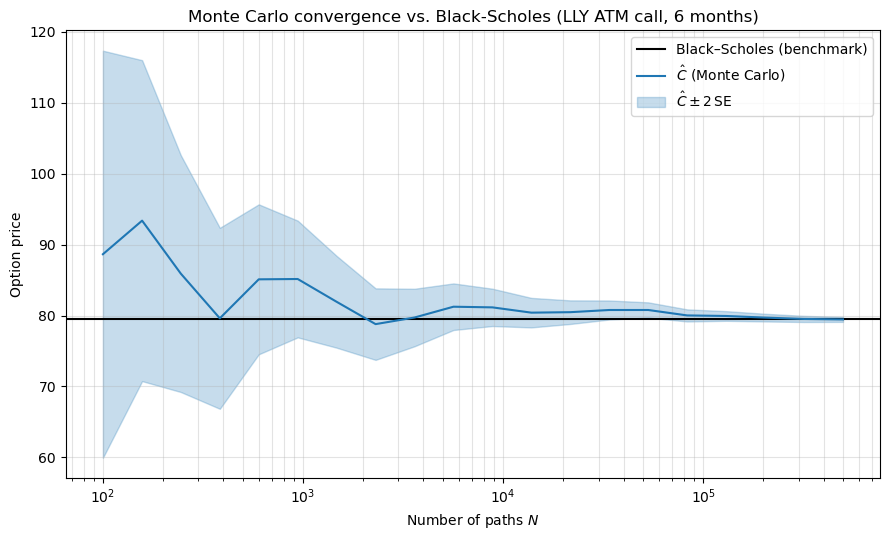

In [ ]:
import time
import pandas as pd
import matplotlib.pyplot as plt


def simulate_terminal_prices_gbm(S0, r, sigma, T, n_steps, n_paths, rng):
    """
    Run the simular for the stock price using Geometric Brownian Motion (gbm)
    """
    dt = T / n_steps  # the size of one time step
    sqrt_dt = np.sqrt(dt)
    S = np.full(
        n_paths, S0, dtype=np.float64
    )  # array of "universes", all starting at S0
    for _ in range(n_steps):
        Z = rng.standard_normal(n_paths)  # Generate random shock

        # Update stock price using Euler-Maruyama
        S = (
            S + r * S * dt + sigma * S * sqrt_dt * Z
        )  # r is drift, sigma is volatility, Z is shock
    return S


rng = np.random.default_rng(mc_seed)  # Set the seed for reproducibility

N_max = 500_000
n_steps = mc_time_steps

t0 = time.perf_counter()
S_T = simulate_terminal_prices_gbm(S0, r, sigma, T, n_steps, N_max, rng)
t_sim = time.perf_counter() - t0

# Discounted payoffs
# If the stock price is above the strike price, the payoff is the difference
# between the stock price and the strike price (keep the profit)
# Otherwise, the option is worth $0
payoff = np.exp(-r * T) * np.maximum(S_T - K, 0.0)

# Path counts N is in the range [100, 500_000]
N_list = np.unique(
    np.clip(
        np.round(np.logspace(2, np.log10(N_max), 20)).astype(int),
        100,
        N_max,
    )
)
if N_list[0] < 100:
    N_list = np.unique(np.concatenate([[100], N_list]))
if N_list[-1] < N_max:
    N_list = np.unique(np.concatenate([N_list, [N_max]]))

rows = []
mc_prices = []
se_list = []

for N in N_list:
    # First N payoffs
    x = payoff[:N]
    # Monte Carlo price is the average of the payoffs
    c_hat = float(np.mean(x))
    # Standard error of average
    se = float(np.std(x, ddof=1) / np.sqrt(N)) if N > 1 else 0.0
    # 95% confidence interval
    ci_lo = c_hat - 1.96 * se
    ci_hi = c_hat + 1.96 * se
    rows.append(
        {
            "N": N,
            "MC_price": c_hat,
            "SE": se,
            "CI_95_low": ci_lo,
            "CI_95_high": ci_hi,
            # Relative error compared to Black-Scholes benchmark
            "rel_err_vs_BS": abs(c_hat - bs_benchmark_price) / bs_benchmark_price,
        }
    )
    mc_prices.append(c_hat)
    se_list.append(se)

mc_table = pd.DataFrame(rows)

# Smallest N on this grid within 1% of Black–Scholes (relative error on point estimate)
within_1pct = mc_table[mc_table["rel_err_vs_BS"] <= 0.01]
N_within_1pct = int(within_1pct["N"].iloc[0]) if len(within_1pct) else None

print("Question 2.2: Monte Carlo (Euler–Maruyama, n = 126 steps, Δt = T/n)")
print(
    f"  Simulated {N_max:,} terminal prices in {t_sim:.3f} s (one stream, nested N for convergence)."
)
print()
if N_within_1pct is not None:
    print(f"  Smallest N on this grid with |MC − BS| / BS ≤ 1%: N = {N_within_1pct:,}")
else:
    print("  No N on this grid reaches |MC − BS| / BS ≤ 1% (try larger N_max).")
print()
print("  MC price, SE, and 95% CI at each N (grid):")
print(mc_table.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print("  (rel_err_vs_BS = |MC_price − BS| / BS_benchmark_price)")
print()

# Create the convergence plot
fig, ax = plt.subplots(figsize=(9, 5.5))
# Black-Scholes benchmark (target)
ax.axhline(
    bs_benchmark_price,
    color="black",
    linestyle="-",
    linewidth=1.5,
    label="Black–Scholes (benchmark)",
)
mc_arr = np.array(mc_prices)
se_arr = np.array(se_list)
# Monte Carlo prices
ax.semilogx(N_list, mc_arr, color="C0", label=r"$\hat{C}$ (Monte Carlo)")
# Shaded area
ax.fill_between(
    N_list,
    mc_arr - 2 * se_arr,
    mc_arr + 2 * se_arr,
    color="C0",
    alpha=0.25,
    label=r"$\hat{C} \pm 2\,\mathrm{SE}$",
)
ax.set_xlabel("Number of paths $N$")
ax.set_ylabel("Option price")
ax.set_title(
    "Monte Carlo convergence vs. Black-Scholes (LLY at-the-money call, 6 months)"
)
ax.legend(loc="upper right")
ax.grid(True, which="both", alpha=0.35)
plt.tight_layout()
plt.show()